In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("../../../CSV/compare_region_basin/region_area.csv")


In [47]:
region_name_map = {
    "USA": "USA",
    "XE25": "EU",
    "XER": "Rest of EU",
    "TUR": "Turkey",
    "XOC": "Oceania",
    "CHN": "China",
    "IND": "India",
    "JPN": "Japan",
    "XSE": "Rest of SE Asia",
    "XSA": "Rest of Asia",
    "CAN": "Canada",
    "BRA": "Brazil",
    "XLM": "Latin America",
    "CIS": "Former USSR",
    "XME": "Middle East",
    "XNF": "North Africa",
    "XAF": "Sub-Sahara Africa",
    "WLD": "World"
}

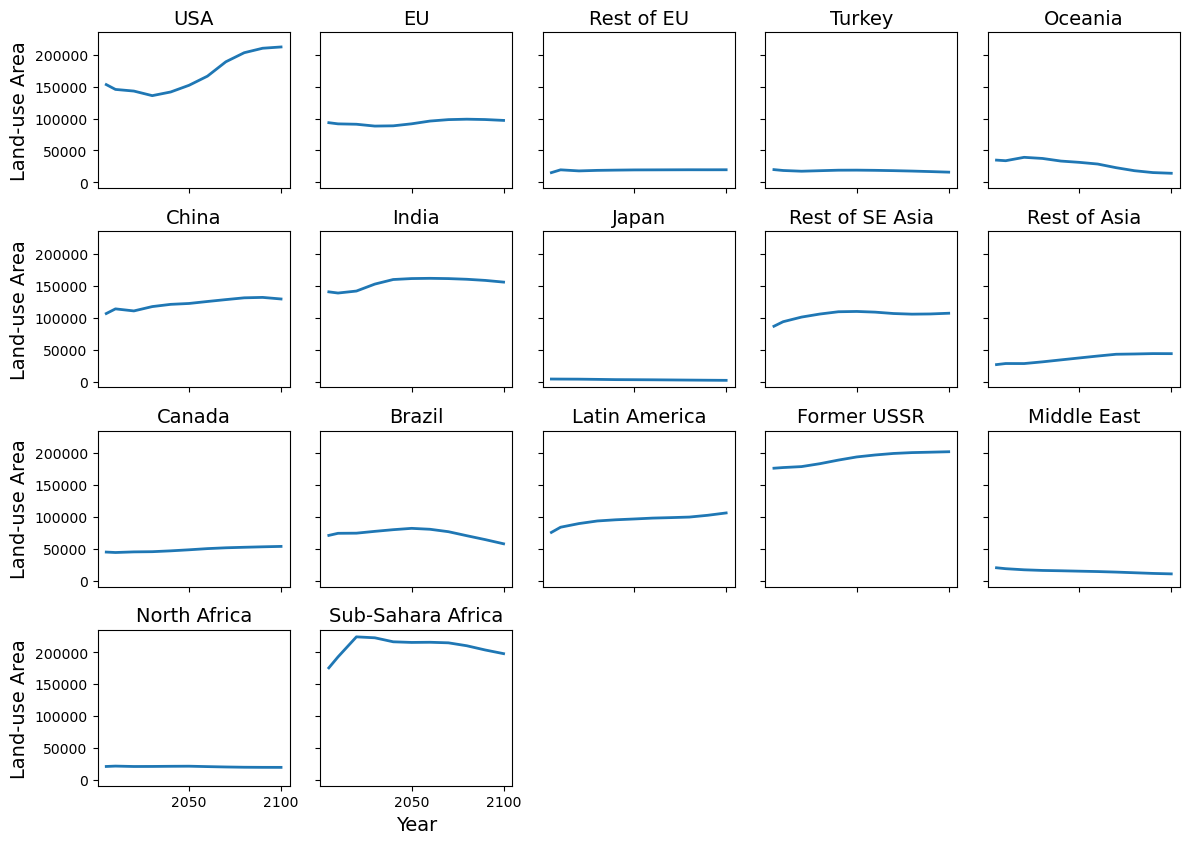

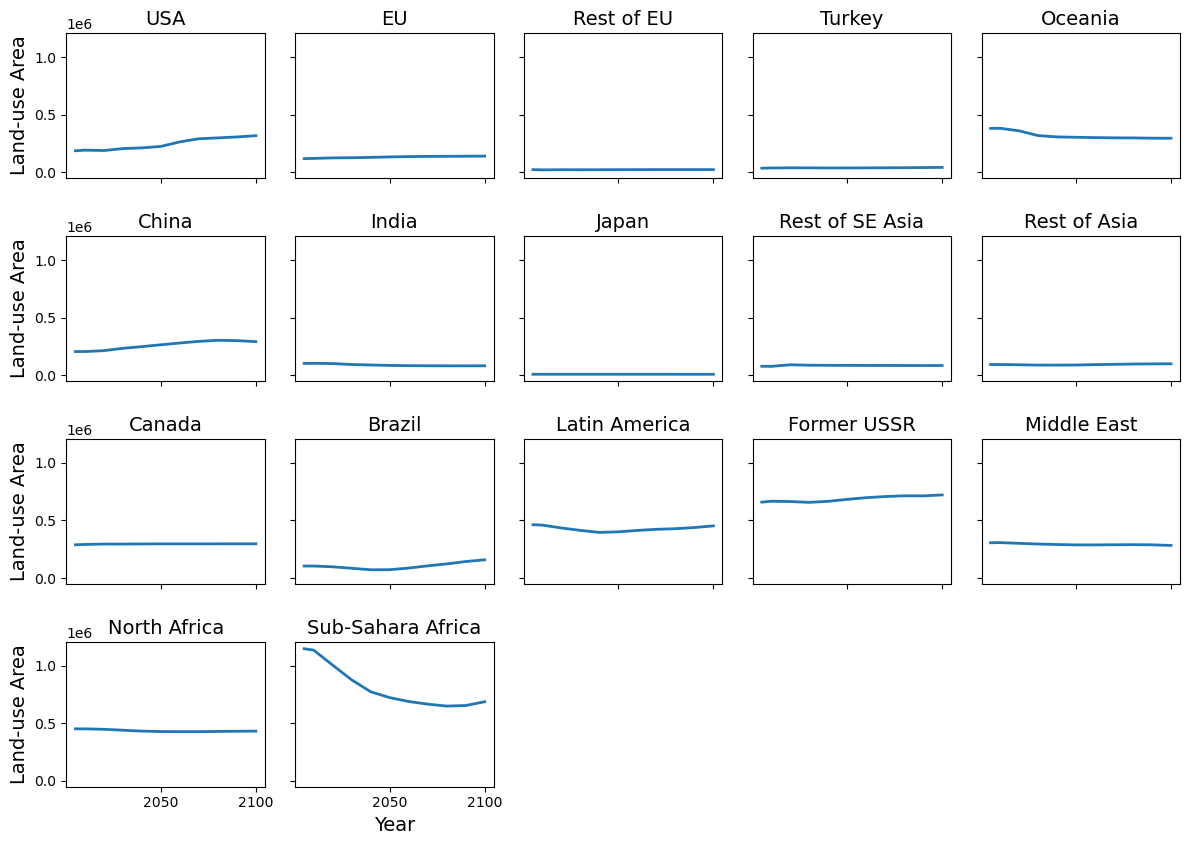

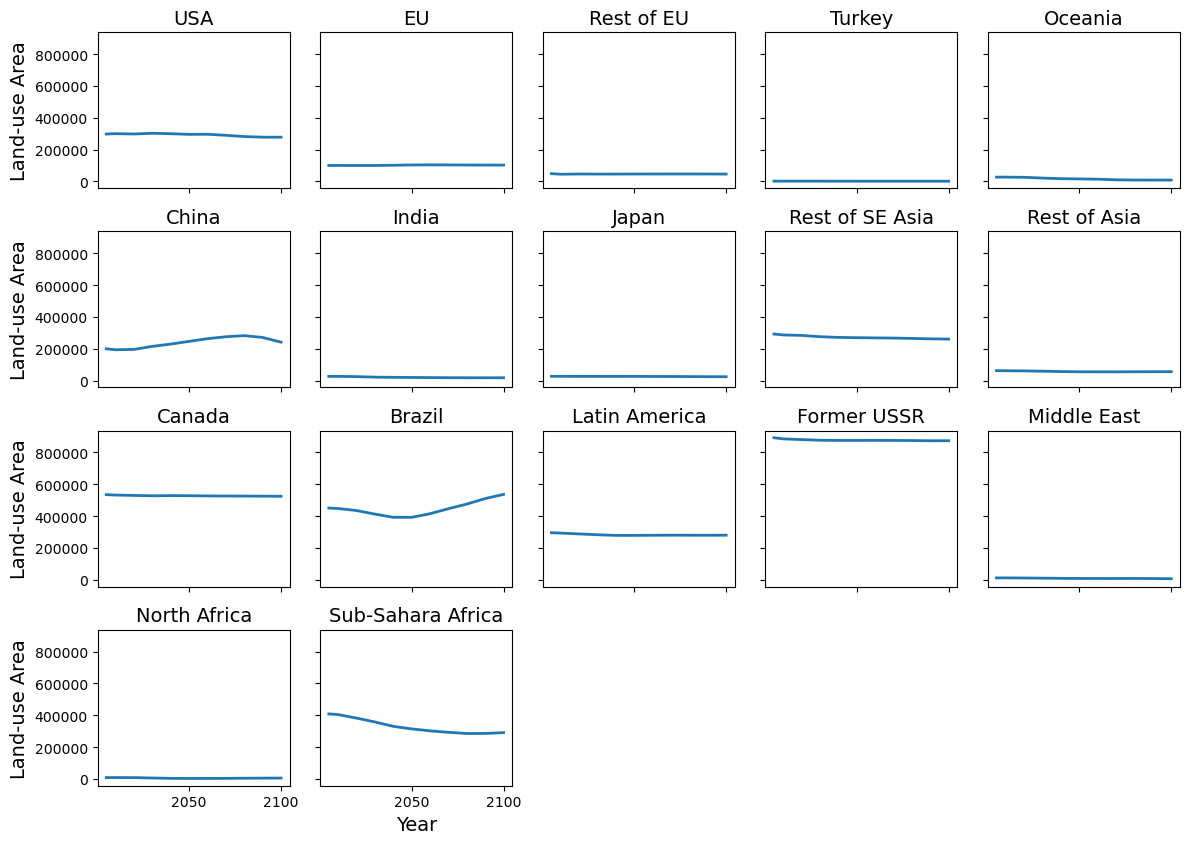

In [48]:
# 指定年份
years = [2005, 2010] + list(range(2020, 2101, 10))
df = df[df["year"].isin(years)]

# 三种类型
types = ["CL", "GL", "FRS"]

# 所有国家（17个）
countries = sorted(df["country"].unique())
countries = [c for c in region_name_map.keys() if c != "WLD"]

# 每个类型画一个大图
for land_type in types:
    
    df_type = df[df["type"] == land_type]
    
    # 创建 5×4 子图（够放17个）
    fig, axes = plt.subplots(4, 5, figsize=(12, 9),        sharex=True,sharey=True)
    axes = axes.flatten()
    
    for i, country in enumerate(countries):
        ax = axes[i]
        
        subset = df_type[df_type["country"] == country]
        subset = subset.sort_values("year")
        
        ax.plot(subset["year"], subset["Value"],label="Input Land-use Area",linewidth=2)
        title = region_name_map.get(country, country)
        ax.set_title(title, fontsize=14)
        if i % 5 == 0:
            ax.set_ylabel("Land-use Area", fontsize=14)

        if i >= 16:   # 最后一行
            ax.set_xlabel("Year", fontsize=14)

    
    # 多余的子图删除
    for j in range(len(countries), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f"../../../plot/analysis/{land_type}_Landuse_Area.png",dpi=500)

    plt.show()